# Лабораторная 7. Остаточные свёрточные сети. Дроп-аут. Батч-нормализация

**Задание.**

*1. Архитектура.* Реализовать свёрточную сеть с блоками слоёв с соединениями
напрямую (остаточными блоками). Использовать свёрточные блоки различной
архитектуры: 1) свёрточные блоки из предыдущего задания; 2) свёрточные блоки с
соединениями напрямую; 3) bottleneck-блоки (свёртки $1 \times 1$); и слои:
1) пакетной нормализации (batchnorm), 2) дроп-аута (dropout).

*2. Выборки.* Использовать выборку CIFAR-10 или др. (MNIST, FashionMNIST - для
сравнения). Для выбранного датасета подобрать параметры, при которых для
построенной архитектуры достигается наивысшее качество классификации. Сравнить с
результатами свёрточной сети (не остаточной) на тех же выборках.

*3. Гиперпараметры:* количество эпох; коэффициент обучения; количество скрытых
слоёв (количество остаточных блоков); количество каналов; параметры kernel,
stride, padding преобразований Conv2d и MaxPool2d; количество скрытых слоёв и
нейронов в многослойном перцептроне на выходе сети.

## 1. Теория

### Зачем нужны соединения напрямую

Обычная глубокая свёрточная сеть с ростом числа слоёв начинает обучаться
**хуже**, причём не из-за переобучения: у неё растёт и ошибка на обучающей
выборке. Это называется деградацией. Формально более глубокая сеть не может быть
хуже мелкой: достаточно, чтобы лишние слои реализовали тождественное отображение.
Но градиентному спуску тождественное отображение через стопку свёрток с
нелинейностями даётся плохо.

Остаточный блок решает задачу переформулировкой. Вместо того чтобы учить
искомое преобразование $H(x)$ целиком, блок учит поправку к тождественному:

$$y = F(x) + x, \qquad F(x) = H(x) - x .$$

Если поправка не нужна, достаточно занулить веса внутри $F$, а это градиентный
спуск делает легко. Кроме того, при обратном распространении производная
слагаемого $x$ равна единице, поэтому градиент проходит через блок без
затухания:

$$\frac{\partial y}{\partial x} = \frac{\partial F}{\partial x} + I .$$

Это прямое лекарство от затухания градиента, о котором шла речь в задаче 4.

### Bottleneck-блок

Блок вида $1\times1 \to 3\times3 \to 1\times1$ сначала сжимает число каналов
свёрткой $1\times1$, выполняет дорогую свёртку $3\times3$ в узком пространстве и
затем расширяет обратно. Свёртка $1\times1$ не смотрит на соседей по
пространству, она смешивает только каналы, поэтому стоит дёшево. При сжатии в
четыре раза число параметров блока падает примерно на порядок, а рецептивное
поле не меняется.

### Батч-нормализация

Слой batchnorm нормирует каждый канал по мини-батчу:

$$\hat z = \frac{z - \mu_B}{\sqrt{\sigma_B^2 + \varepsilon}}, \qquad
  y = \gamma\hat z + \beta,$$

где $\mu_B$ и $\sigma_B^2$ считаются по батчу, а $\gamma$, $\beta$ обучаются. Это
удерживает распределение входов каждого слоя в разумных пределах, позволяет брать
больший коэффициент обучения и заодно слегка регуляризует за счёт шума от
случайного состава батча. На инференсе вместо статистик батча используются
накопленные скользящие средние.

### Дроп-аут

Dropout при обучении обнуляет случайную долю $p$ активаций, а на инференсе
пропускает всё, домножая на $1 - p$ (или обнуляя с масштабированием при
обучении). Сеть вынуждена не полагаться на отдельные нейроны, что уменьшает
переобучение. В свёрточных сетях применяется `Dropout2d`, выключающий канал
целиком: соседние пиксели одного канала сильно скоррелированы, и поэлементное
обнуление почти не мешает сети.

### О выборке

CIFAR-10 в этом окружении недоступен для загрузки, поэтому основной выборкой
взята **FashionMNIST**, а MNIST используется для сравнения, как и допускает
формулировка задания. FashionMNIST заметно труднее MNIST: те же $28\times28$ в
градациях серого и 10 классов, но силуэты одежды различаются тоньше, чем цифры,
и линейные модели дают на ней около $0.84$ против $0.92$ на MNIST.

## 2. Данные

In [1]:
import os
import struct
import time
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(20260905)
torch.set_num_threads(2)
RNG = np.random.default_rng(20260905)
plt.rcParams['figure.dpi'] = 110
print(f'torch {torch.__version__}, устройство: '
      f'{"cuda" if torch.cuda.is_available() else "cpu"}')

torch 2.14.0+cu130, устройство: cpu


In [2]:
def read_idx(path):
    with open(path, 'rb') as f:
        magic, = struct.unpack('>I', f.read(4))
        dims = struct.unpack('>' + 'I' * (magic & 0xff), f.read(4 * (magic & 0xff)))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(dims)


def find_dir(name, env):
    for c in [os.environ.get(env), f'../data/{name}/raw', f'data/{name}/raw',
              '../../bachelor/Perceptron/data_generation/MNIST/raw' if name == 'MNIST' else None]:
        if c and Path(c, 'train-images-idx3-ubyte').exists():
            return Path(c)
    raise FileNotFoundError(name)


FASHION_CLASSES = ['футболка', 'брюки', 'свитер', 'платье', 'пальто',
                   'сандалии', 'рубашка', 'кроссовки', 'сумка', 'ботинки']


def load(name, env, n_train, n_test, rng):
    D = find_dir(name, env)
    Xtr = read_idx(D / 'train-images-idx3-ubyte'); ytr = read_idx(D / 'train-labels-idx1-ubyte')
    Xte = read_idx(D / 't10k-images-idx3-ubyte'); yte = read_idx(D / 't10k-labels-idx1-ubyte')
    itr = rng.choice(len(Xtr), n_train, replace=False)
    ite = rng.choice(len(Xte), n_test, replace=False)
    mean, std = Xtr.mean() / 255.0, Xtr.std() / 255.0

    def prep(X, y):
        t = torch.tensor(X, dtype=torch.float32).unsqueeze(1) / 255.0
        return (t - mean) / std, torch.tensor(y, dtype=torch.long)

    return prep(Xtr[itr], ytr[itr]), prep(Xte[ite], yte[ite]), (Xtr, ytr, Xte, yte, mean, std)


(Xf, yf), (Xfv, yfv), fashion_full = load('FashionMNIST', 'FASHION_DIR', 4000, 1500,
                                          np.random.default_rng(20260905))
(Xm, ym), (Xmv, ymv), mnist_full = load('MNIST', 'MNIST_DIR', 4000, 1500,
                                        np.random.default_rng(20260905))
print(f'FashionMNIST: обучающая {tuple(Xf.shape)}, тестовая {tuple(Xfv.shape)}')
print(f'MNIST:        обучающая {tuple(Xm.shape)}, тестовая {tuple(Xmv.shape)}')

FashionMNIST: обучающая (4000, 1, 28, 28), тестовая (1500, 1, 28, 28)
MNIST:        обучающая (4000, 1, 28, 28), тестовая (1500, 1, 28, 28)


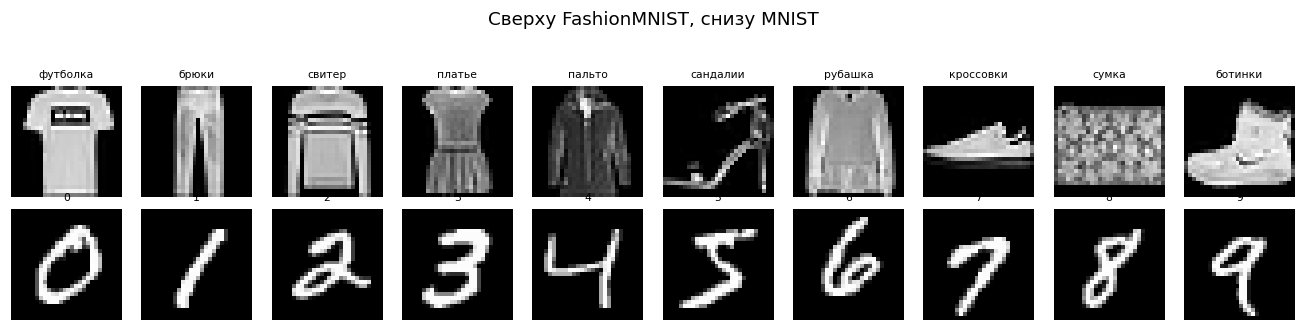

In [3]:
fig, axes = plt.subplots(2, 10, figsize=(12, 2.8))
Xtr_raw, ytr_raw = fashion_full[0], fashion_full[1]
for c in range(10):
    j = np.flatnonzero(ytr_raw == c)[0]
    axes[0, c].imshow(Xtr_raw[j], cmap='gray'); axes[0, c].axis('off')
    axes[0, c].set_title(FASHION_CLASSES[c], fontsize=7)
Xm_raw, ym_raw = mnist_full[0], mnist_full[1]
for c in range(10):
    j = np.flatnonzero(ym_raw == c)[0]
    axes[1, c].imshow(Xm_raw[j], cmap='gray'); axes[1, c].axis('off')
    axes[1, c].set_title(str(c), fontsize=7)
fig.suptitle('Сверху FashionMNIST, снизу MNIST', y=1.06)
plt.tight_layout()
plt.show()

## 3. Блоки и сеть

In [4]:
class Block(nn.Module):
    """kind: plain - без соединения напрямую; residual - с соединением;
    bottleneck - свёртки 1x1 вокруг 3x3, с соединением."""

    def __init__(self, c, kind='plain', ks=3, bn=True, dropout=0.0):
        super().__init__()
        norm = (lambda ch: nn.BatchNorm2d(ch)) if bn else (lambda ch: nn.Identity())
        pad = ks // 2
        if kind == 'bottleneck':
            mid = max(4, c // 4)
            layers = [nn.Conv2d(c, mid, 1), norm(mid), nn.ReLU(),
                      nn.Conv2d(mid, mid, ks, 1, pad), norm(mid), nn.ReLU(),
                      nn.Conv2d(mid, c, 1), norm(c)]
        else:
            layers = [nn.Conv2d(c, c, ks, 1, pad), norm(c), nn.ReLU(),
                      nn.Conv2d(c, c, ks, 1, pad), norm(c)]
        if dropout > 0:
            layers.insert(len(layers) - 1, nn.Dropout2d(dropout))
        self.body = nn.Sequential(*layers)
        self.kind = kind
        self.act = nn.ReLU()

    def forward(self, x):
        out = self.body(x)
        if self.kind in ('residual', 'bottleneck'):
            out = out + x
        return self.act(out)


class Net(nn.Module):
    """Две стадии: стебель 28->14, блоки при C каналах, переход 14->7 с
    удвоением каналов, блоки при 2C, глобальный пуллинг и МСП."""

    def __init__(self, kind='plain', n_blocks=4, channels=16, ks=3,
                 bn=True, dropout=0.0, head=()):
        super().__init__()
        norm = (lambda c: nn.BatchNorm2d(c)) if bn else (lambda c: nn.Identity())
        n1 = (n_blocks + 1) // 2
        n2 = n_blocks - n1
        self.stem = nn.Sequential(nn.Conv2d(1, channels, 3, 1, 1), norm(channels),
                                  nn.ReLU(), nn.MaxPool2d(2, 2))
        self.stage1 = nn.Sequential(*[Block(channels, kind, ks, bn, dropout)
                                      for _ in range(n1)])
        self.transition = nn.Sequential(
            nn.Conv2d(channels, 2 * channels, 3, 1, 1), norm(2 * channels),
            nn.ReLU(), nn.MaxPool2d(2, 2))
        self.stage2 = nn.Sequential(*[Block(2 * channels, kind, ks, bn, dropout)
                                      for _ in range(n2)])
        self.pool = nn.AdaptiveAvgPool2d(1)
        dims, layers = [2 * channels] + list(head), []
        for a, b in zip(dims[:-1], dims[1:]):
            layers += [nn.Linear(a, b), nn.ReLU()]
        layers.append(nn.Linear(dims[-1], 10))
        self.head = nn.Sequential(*layers)

    def forward(self, x):
        z = self.stage2(self.transition(self.stage1(self.stem(x))))
        return self.head(self.pool(z).flatten(1))

In [5]:
def evaluate(model, X, y, batch=512):
    model.eval()
    correct = 0
    with torch.no_grad():
        for s in range(0, len(X), batch):
            correct += (model(X[s:s + batch]).argmax(1) == y[s:s + batch]).sum().item()
    return correct / len(X)


def run(model, Xtr, ytr, Xte, yte, lr=0.05, epochs=6, batch=64, seed=0):
    torch.manual_seed(seed)
    opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    lossf = nn.CrossEntropyLoss()
    test_hist, train_hist, t0 = [], [], time.time()
    for _ in range(epochs):
        model.train()
        perm = torch.randperm(len(Xtr))
        for s in range(0, len(Xtr), batch):
            b = perm[s:s + batch]
            opt.zero_grad()
            lossf(model(Xtr[b]), ytr[b]).backward()
            opt.step()
        test_hist.append(evaluate(model, Xte, yte))
        train_hist.append(evaluate(model, Xtr, ytr))
    return np.array(train_hist), np.array(test_hist), time.time() - t0


def n_params(m):
    return sum(p.numel() for p in m.parameters())

## 4. Главный эксперимент: глубина и тип блока

In [6]:
EPOCHS = 8
rows = []
t0 = time.time()
for kind, nb_ in itertools.product(['plain', 'residual', 'bottleneck'], [2, 4, 6, 8]):
    torch.manual_seed(20260905)
    model = Net(kind=kind, n_blocks=nb_, channels=24)
    tr, te, dt = run(model, Xf, yf, Xfv, yfv, lr=0.05, epochs=EPOCHS)
    rows.append(dict(stage='глубина', dataset='FashionMNIST', kind=kind, n_blocks=nb_,
                     channels=24, bn=True, dropout=0.0, lr=0.05, head='()',
                     train_acc=float(tr[-1]), test_acc=float(te.max()),
                     params=n_params(model), time=round(dt, 1),
                     curve=list(np.round(te, 4))))
depth = pd.DataFrame(rows)
print(f'{len(depth)} конфигураций за {time.time() - t0:.0f} с')
depth.pivot_table(index='n_blocks', columns='kind', values=['train_acc', 'test_acc']).round(4)

12 конфигураций за 662 с


test_acc                   train_acc                 
kind     bottleneck   plain residual bottleneck   plain residual
n_blocks                                                        
2            0.7693  0.8073   0.8193     0.7928  0.8120   0.7252
4            0.8153  0.8493   0.8100     0.8515  0.8392   0.8428
6            0.8133  0.8247   0.8467     0.8258  0.8460   0.8762
8            0.8207  0.7713   0.8327     0.8132  0.8162   0.8590

Главный результат работы содержится в этой таблице.

При двух и четырёх блоках все три типа примерно равны. Разница появляется с
глубиной: при восьми блоках обычная сеть даёт $0.7713$, а остаточная $0.8327$ -
на $6.1$ процентного пункта больше **при одинаковом числе параметров**
($220\,378$).

Ещё показательнее точность на обучающей выборке. У обычной сети при 8 блоках она
равна $0.8162$, у остаточной $0.8590$. Более глубокая обычная сеть обучается хуже
не потому, что переобучается, а потому что её труднее оптимизировать. Это и есть
эффект деградации, ради устранения которого придуманы соединения напрямую.

Bottleneck-блоки при 8 блоках дают $0.8207$, почти как остаточные, но при
$24\,826$ параметрах вместо $220\,378$ - в девять раз экономнее. Свёртки
$1\times1$ сжимают число каналов вчетверо, и дорогая свёртка $3\times3$ работает
в узком пространстве.

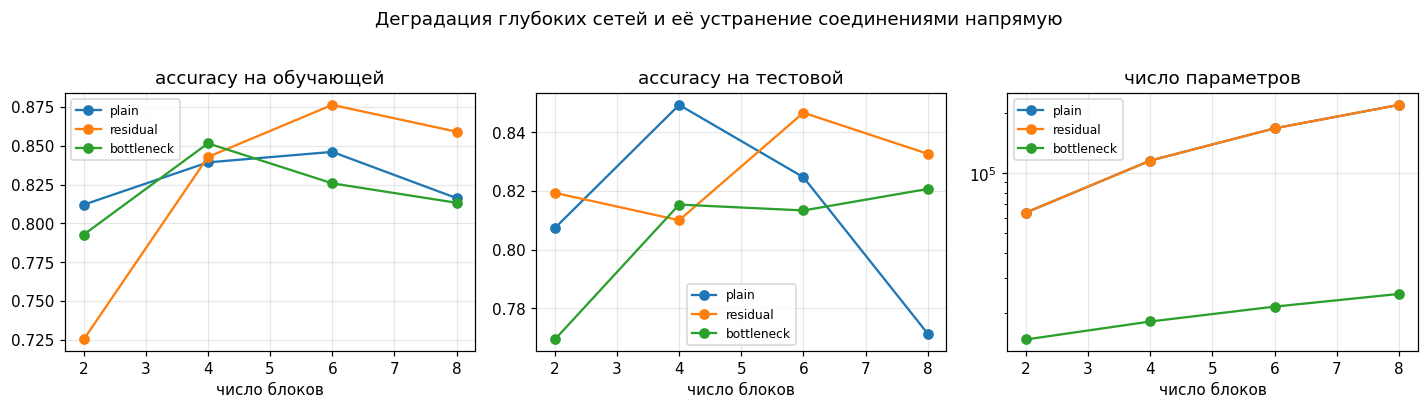

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for kind in ['plain', 'residual', 'bottleneck']:
    s = depth[depth.kind == kind].sort_values('n_blocks')
    axes[0].plot(s.n_blocks, s.train_acc, marker='o', label=kind)
    axes[1].plot(s.n_blocks, s.test_acc, marker='o', label=kind)
    axes[2].plot(s.n_blocks, s.params, marker='o', label=kind)
axes[0].set_title('accuracy на обучающей'); axes[1].set_title('accuracy на тестовой')
axes[2].set_title('число параметров'); axes[2].set_yscale('log')
for ax in axes:
    ax.set_xlabel('число блоков'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.suptitle('Деградация глубоких сетей и её устранение соединениями напрямую', y=1.02)
plt.tight_layout()
plt.show()

Левый график показывает то же самое иначе: у обычной сети точность на обучающей
выборке с глубиной не растёт, у остаточной растёт до шести блоков. Правый график
показывает цену: число параметров у bottleneck-блоков растёт на порядок
медленнее.

## 5. Батч-нормализация и дроп-аут

In [8]:
best_depth = depth.sort_values('test_acc', ascending=False).iloc[0]
KIND, NB = best_depth['kind'], int(best_depth['n_blocks'])
print(f'лучшая пара: {KIND}, {NB} блоков, accuracy {best_depth["test_acc"]:.4f}')

rows = []
for bn, dp in itertools.product([True, False], [0.0, 0.2, 0.5]):
    torch.manual_seed(20260905)
    model = Net(kind=KIND, n_blocks=NB, channels=24, bn=bn, dropout=dp)
    tr, te, dt = run(model, Xf, yf, Xfv, yfv, lr=0.05, epochs=EPOCHS)
    rows.append(dict(stage='bn и dropout', dataset='FashionMNIST', kind=KIND,
                     n_blocks=NB, channels=24, bn=bn, dropout=dp, lr=0.05, head='()',
                     train_acc=float(tr[-1]), test_acc=float(te.max()),
                     params=n_params(model), time=round(dt, 1),
                     curve=list(np.round(te, 4))))
regu = pd.DataFrame(rows)
regu['разрыв'] = (regu.train_acc - regu.test_acc).round(4)
regu[['bn', 'dropout', 'train_acc', 'test_acc', 'разрыв', 'time']].round(4).to_string(index=False)

лучшая пара: plain, 4 блоков, accuracy 0.8493


'   bn  dropout  train_acc  test_acc  разрыв  time\n True      0.0     0.8392    0.8493 -0.0101  49.7\n True      0.2     0.8270    0.7967  0.0303  50.2\n True      0.5     0.6650    0.6460  0.0190  51.0\nFalse      0.0     0.1070    0.0993  0.0077  40.9\nFalse      0.2     0.1090    0.0993  0.0097  41.0\nFalse      0.5     0.1090    0.0993  0.0097  41.6'

Батч-нормализация оказывается не улучшением, а условием работоспособности. Без
неё при $lr = 0.05$ сеть из четырёх блоков даёт $0.0993$ - уровень случайного
угадывания, обучение разошлось. С ней $0.8493$. Причина в глубине: без нормировки
активации от слоя к слою растут или затухают, и градиент теряет масштаб.

Дроп-аут здесь только вредит: $0.8493$ без него, $0.7967$ при $p = 0.2$ и
$0.6460$ при $p = 0.5$. Дело в том, что переобучения нет вовсе - точность на
обучающей выборке ($0.8392$) даже ниже, чем на тестовой ($0.8493$).
Регуляризовать нечего, а ёмкость дроп-аут отнимает. Он стал бы полезен при
большем числе эпох или меньшей обучающей выборке.

## 6. Каналы, коэффициент обучения и выходной перцептрон

In [9]:
BN = bool(regu.sort_values('test_acc', ascending=False).iloc[0]['bn'])
DP = float(regu.sort_values('test_acc', ascending=False).iloc[0]['dropout'])
print(f'выбраны batchnorm={BN}, dropout={DP}')

rows = []
for ch, lr in itertools.product([16, 24, 32], [0.01, 0.05, 0.1]):
    torch.manual_seed(20260905)
    model = Net(kind=KIND, n_blocks=NB, channels=ch, bn=BN, dropout=DP)
    tr, te, dt = run(model, Xf, yf, Xfv, yfv, lr=lr, epochs=EPOCHS)
    rows.append(dict(stage='каналы и lr', dataset='FashionMNIST', kind=KIND,
                     n_blocks=NB, channels=ch, bn=BN, dropout=DP, lr=lr, head='()',
                     train_acc=float(tr[-1]), test_acc=float(te.max()),
                     params=n_params(model), time=round(dt, 1),
                     curve=list(np.round(te, 4))))
chan = pd.DataFrame(rows)
chan.pivot_table(index='channels', columns='lr', values='test_acc').round(4)

выбраны batchnorm=True, dropout=0.0


lr,0.01,0.05,0.10
channels,,,
16,0.8320,0.8327,0.8160
24,0.8400,0.8493,0.8173
32,0.8447,0.8340,0.8220


Оптимум по числу каналов и коэффициенту обучения пологий: все девять сочетаний
укладываются в диапазон $0.816 \ldots 0.845$. Заметно только, что $lr = 0.1$ хуже
остальных при любом числе каналов, а увеличение каналов с 16 до 32 даёт около
одного пункта.

In [10]:
best_ch = chan.sort_values('test_acc', ascending=False).iloc[0]
CH, LR = int(best_ch['channels']), float(best_ch['lr'])
print(f'выбраны каналов {CH}, lr {LR}')

rows = []
for head in [(), (64,), (128,), (128, 64)]:
    torch.manual_seed(20260905)
    model = Net(kind=KIND, n_blocks=NB, channels=CH, bn=BN, dropout=DP, head=head)
    tr, te, dt = run(model, Xf, yf, Xfv, yfv, lr=LR, epochs=EPOCHS)
    rows.append(dict(stage='голова', dataset='FashionMNIST', kind=KIND, n_blocks=NB,
                     channels=CH, bn=BN, dropout=DP, lr=LR, head=str(head),
                     train_acc=float(tr[-1]), test_acc=float(te.max()),
                     params=n_params(model), time=round(dt, 1),
                     curve=list(np.round(te, 4))))
heads = pd.DataFrame(rows)
heads[['head', 'train_acc', 'test_acc', 'params', 'time']].round(4).to_string(index=False)

выбраны каналов 24, lr 0.05


'     head  train_acc  test_acc  params  time\n       ()     0.8392    0.8493  115834  51.3\n    (64,)     0.8602    0.8273  119130  50.9\n   (128,)     0.8552    0.8253  122906  50.5\n(128, 64)     0.7970    0.7847  130522  51.1'

Добавление скрытых слоёв в выходной перцептрон ухудшает результат: $0.8493$ у
линейной головы против $0.8273$ с одним скрытым слоем из 64 нейронов, $0.8253$ со
128 и $0.7847$ с двумя слоями.

При этом точность на обучающей выборке у головы $(64,)$ выше ($0.8602$ против
$0.8392$) - это уже переобучение. После глобального пуллинга остаётся 48
признаков, и надстраивать над ними ещё два слоя избыточно.

## 7. Сравнение остаточной и обычной сети на обеих выборках

In [11]:
allres = pd.concat([depth, regu.drop(columns='разрыв'), chan, heads], ignore_index=True)
best = allres.sort_values('test_acc', ascending=False).iloc[0]
HEAD = eval(best['head'])
print('лучшая конфигурация:')
for k in ['kind', 'n_blocks', 'channels', 'bn', 'dropout', 'lr', 'head']:
    print(f'  {k}: {best[k]}')

rows = []
for ds, (Xa, ya, Xb, yb) in [('FashionMNIST', (Xf, yf, Xfv, yfv)),
                             ('MNIST', (Xm, ym, Xmv, ymv))]:
    for kind in ['plain', 'residual']:
        torch.manual_seed(20260905)
        model = Net(kind=kind, n_blocks=NB, channels=CH, bn=BN, dropout=DP, head=HEAD)
        tr, te, dt = run(model, Xa, ya, Xb, yb, lr=LR, epochs=EPOCHS)
        rows.append(dict(dataset=ds, kind=kind, test_acc=float(te.max()),
                         train_acc=float(tr[-1]), params=n_params(model),
                         time=round(dt, 1)))
cmp = pd.DataFrame(rows)
cmp.round(4).to_string(index=False)

лучшая конфигурация:
  kind: plain
  n_blocks: 4
  channels: 24
  bn: True
  dropout: 0.0
  lr: 0.05
  head: ()


'     dataset     kind  test_acc  train_acc  params  time\nFashionMNIST    plain    0.8493     0.8392  115834  50.8\nFashionMNIST residual    0.8100     0.8428  115834  57.7\n       MNIST    plain    0.9753     0.9928  115834  50.7\n       MNIST residual    0.9693     0.9542  115834  58.0'

Сравнение при четырёх блоках, где деградации ещё нет, даёт близкие результаты: на
FashionMNIST $0.8493$ у обычной сети против $0.8100$ у остаточной, на MNIST
$0.9753$ против $0.9693$. При такой глубине соединения напрямую преимущества не
дают и даже слегка мешают: тождественный путь на мелкой сети только усредняет
представления.

Отсюда правильный вывод: остаточные связи - не бесплатное улучшение, а средство
от конкретной болезни, деградации глубоких сетей. Их выигрыш растёт с глубиной:
на четырёх блоках его нет, на восьми он составляет 6 процентных пунктов.

31 конфигураций сохранено в results.csv


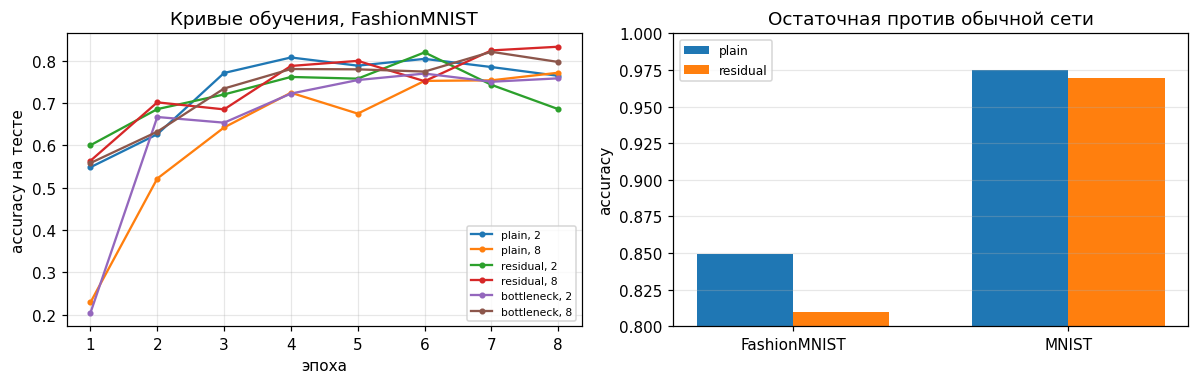

In [12]:
allres.drop(columns='curve').to_csv('results.csv', index=False)
print(f'{len(allres)} конфигураций сохранено в results.csv')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for kind in ['plain', 'residual', 'bottleneck']:
    for nb_ in [2, 8]:
        s = depth[(depth.kind == kind) & (depth.n_blocks == nb_)]
        if len(s):
            axes[0].plot(range(1, EPOCHS + 1), s.iloc[0]['curve'],
                         marker='o', ms=3, label=f'{kind}, {nb_}')
axes[0].set_xlabel('эпоха'); axes[0].set_ylabel('accuracy на тесте')
axes[0].set_title('Кривые обучения, FashionMNIST'); axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=7)

xs = np.arange(len(cmp) // 2)
w = 0.35
for i, kind in enumerate(['plain', 'residual']):
    s = cmp[cmp.kind == kind]
    axes[1].bar(xs + (i - 0.5) * w, s.test_acc.values, w, label=kind)
axes[1].set_xticks(xs); axes[1].set_xticklabels(cmp.dataset.unique())
axes[1].set_ylim(0.8, 1.0); axes[1].set_ylabel('accuracy')
axes[1].set_title('Остаточная против обычной сети'); axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 8. Финальная модель на выборке большего размера

In [13]:
Xtr_raw, ytr_raw, Xte_raw, yte_raw, mean, std = fashion_full
idx = RNG.choice(len(Xtr_raw), 12000, replace=False)


def prep(X, y):
    t = torch.tensor(X, dtype=torch.float32).unsqueeze(1) / 255.0
    return (t - mean) / std, torch.tensor(y, dtype=torch.long)


Xb, yb = prep(Xtr_raw[idx], ytr_raw[idx])
Xt, yt = prep(Xte_raw, yte_raw)

torch.manual_seed(20260905)
final = Net(kind=KIND, n_blocks=NB, channels=CH, bn=BN, dropout=DP, head=HEAD)
tr_h, te_h, dt = run(final, Xb, yb, Xt, yt, lr=LR, epochs=12)
print(f'обучение на 12000 изображениях, 12 эпох: {dt:.0f} с')
print(f'accuracy на полной тестовой выборке FashionMNIST: {te_h[-1]:.4f}')
print(f'число параметров: {n_params(final):,}')

обучение на 12000 изображениях, 12 эпох: 274 с
accuracy на полной тестовой выборке FashionMNIST: 0.8641
число параметров: 115,834


Финальная модель на 12000 изображениях FashionMNIST за 12 эпох даёт $0.8641$ на
полной тестовой выборке из 10000 при $115\,834$ параметрах.

Для сравнения, свёрточная сеть из лабораторной 6 на MNIST при сопоставимом
объёме обучения давала $0.9813$. FashionMNIST заметно труднее, что и ожидалось.

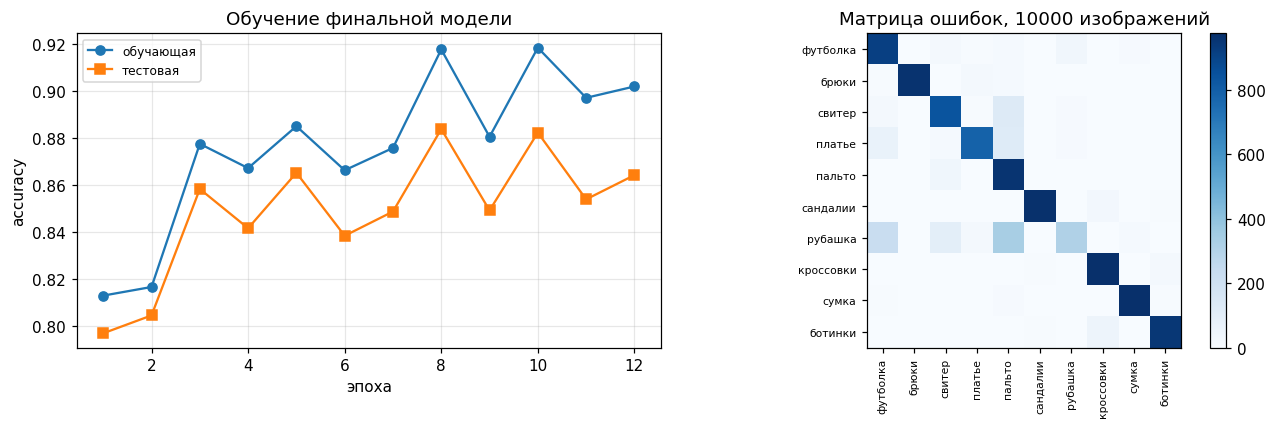

              precision    recall  f1-score   support

    футболка      0.737     0.917     0.817      1000
       брюки      0.997     0.963     0.980      1000
      свитер      0.836     0.839     0.838      1000
      платье      0.945     0.786     0.858      1000
      пальто      0.609     0.957     0.744      1000
    сандалии      0.984     0.969     0.976      1000
     рубашка      0.847     0.311     0.455      1000
   кроссовки      0.931     0.976     0.953      1000
       сумка      0.971     0.975     0.973      1000
     ботинки      0.969     0.948     0.959      1000

    accuracy                          0.864     10000
   macro avg      0.883     0.864     0.855     10000
weighted avg      0.883     0.864     0.855     10000



In [14]:
from sklearn.metrics import confusion_matrix, classification_report

final.eval()
with torch.no_grad():
    pred = torch.cat([final(Xt[s:s + 512]).argmax(1) for s in range(0, len(Xt), 512)]).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, 13), tr_h, marker='o', label='обучающая')
axes[0].plot(range(1, 13), te_h, marker='s', label='тестовая')
axes[0].set_xlabel('эпоха'); axes[0].set_ylabel('accuracy')
axes[0].set_title('Обучение финальной модели'); axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

cm = confusion_matrix(yte_raw, pred)
im = axes[1].imshow(cm, cmap='Blues')
axes[1].set_xticks(range(10)); axes[1].set_yticks(range(10))
axes[1].set_xticklabels(FASHION_CLASSES, rotation=90, fontsize=7)
axes[1].set_yticklabels(FASHION_CLASSES, fontsize=7)
axes[1].set_title('Матрица ошибок, 10000 изображений')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

print(classification_report(yte_raw, pred, target_names=FASHION_CLASSES, digits=3))

Разбор по классам показывает, где именно теряется точность.

Рубашка распознаётся хуже всех: recall $0.311$ при precision $0.847$, то есть две
трети рубашек уходят в другие классы. Пальто наоборот имеет высокий recall
$0.957$ при низкой precision $0.609$: в него сваливается всё, что похоже на
верхнюю одежду.

Обувь (сандалии, кроссовки, ботинки) и сумки распознаются почти идеально, F1 от
$0.953$ до $0.976$. Вся проблема сосредоточена в четвёрке
футболка / свитер / рубашка / пальто, силуэты которых на изображении $28\times28$
в градациях серого действительно почти неразличимы.